<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
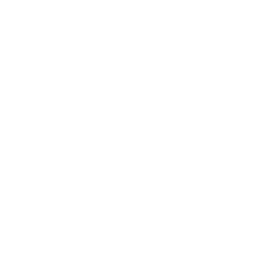
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Industrial Bearing Wear Detection</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Reliability Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Flota 100 łożysk przemysłowych jest monitorowana według stałego harmonogramu konserwacji. Zużycie przekraczające próg tolerancji można wykryć tylko podczas planowych przestojów, więc czas do wystąpienia zużycia nigdy nie jest obserwowany dokładnie — jest **ucięty przedziałowo** między ostatnią kontrolą, która wypadła pomyślnie (`last_ok_hours`), a pierwszą kontrolą, która wykazała zużycie (`first_worn_hours`). Łożyska nadal mieszczące się w tolerancji podczas ostatniej kontroli są ucięte prawostronnie.

PROC ICLIFETEST dopasowuje nieparametryczny estymator Turnbulla funkcji przeżycia wolnego od zużycia i porównuje dwa reżimy smarowania (Syntetyczny vs Mineralny). Analiza odpowiada na konkretne pytanie eksploatacyjne: **czy smar syntetyczny istotnie wydłuża żywotność łożyska wolną od zużycia?** Każda przywołana poniżej liczba pochodzi bezpośrednio z wykonanego wyniku procedury.

## Źródło danych

| Zbiór danych | N | Opis |
|---------|---|-------------|
| `bearing_inspections` | 100 | Jeden wiersz na łożysko: rodzaj smaru, obciążenie, prędkość obrotowa oraz przedział kontroli obejmujący początek zużycia |

Odpowiedzią ucięta przedziałowo jest para `(last_ok_hours, first_worn_hours)`. Brak wartości `first_worn_hours` oznacza łożysko, które nadal mieściło się w tolerancji podczas ostatniej kontroli (ucięcie prawostronne).

---

In [1]:
/* Dane inspekcji zużycia łożysk: 100 łożysk, dwa reżimy smarowania.
   Smar Syntetyczny jest celowo zaprojektowany w danych tak, aby wydłużać
   żywotność wolną od zużycia, dzięki czemu krzywe przeżycia rozdzielają się
   w fizycznie wiarygodnym kierunku. */
DANE bearing_inspections;
    CALL streaminit(42);
    TABLICA lubes[2] $16 ('Syntetyczny' 'Mineralny');
    POWTÓRZ bearing_id = 1 TO 100;
        lubricant = lubes[ceil(rand('uniform') * 2)];
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Warstwa syntetyczna opóźnia początek mierzalnego zużycia */
        JEŚLI lubricant = 'Syntetyczny' WTEDY BASE = 2600; PRZECIWNIE BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% wciąż wolnych od zużycia przy ostatniej kontroli -> ucięcie prawostronne */
        JEŚLI rand('uniform') > 0.75 WTEDY first_worn_hours = .;
        WYJŚCIE;
    KONIEC;
    USUŃ i BASE;
    ZACHOWAJ bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
WYKONAJ;


NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Warunki pracy według rodzaju smaru

Przed modelowaniem przeżycia podsumowujemy rzeczywiste obciążenie eksploatacyjne każdej grupy smaru, aby ewentualna różnica w żywotności wolnej od zużycia nie była po prostu efektem różnic w obciążeniu lub prędkości.

In [2]:
/* Obciążenie eksploatacyjne według reżimu smarowania */
PROCEDURA ŚREDNIE DANE=bearing_inspections n mean std MAX maxdec=1;
    ZMIENNA load_kn rpm;
    KLASA lubricant;
    ETYKIETA lubricant='Rodzaj smaru' load_kn='Obciążenie (kN)' rpm='Prędkość obrotowa (obr/min)';
WYKONAJ;

                                                  The MEANS Procedure

                                     Analysis Variable : load_kn Obciążenie (kN)

        Rodzaj smaru          N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineralny                47           21.5            9.9           51.7
        Syntetyczny              53           25.8           14.0           64.6
        ------------------------------------------------------------------------

                                 Analysis Variable : rpm Prędkość obrotowa (obr/min)

        Rodzaj smaru          N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineralny                47         2786.0         1093.5         4988.1
        Syntetyczny              53         2949.7         1070.5         4773.5
        -----------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Okno kontrolne a obciążenie robocze

Każdy punkt to jedno łożysko. Pozycja pionowa to ostatnia godzina, w której potwierdzono, że łożysko mieści się w tolerancji; kolor oznacza rodzaj smaru. Wykres pokazuje surowy wzorzec ekspozycji zasilający model ucięty przedziałowo.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


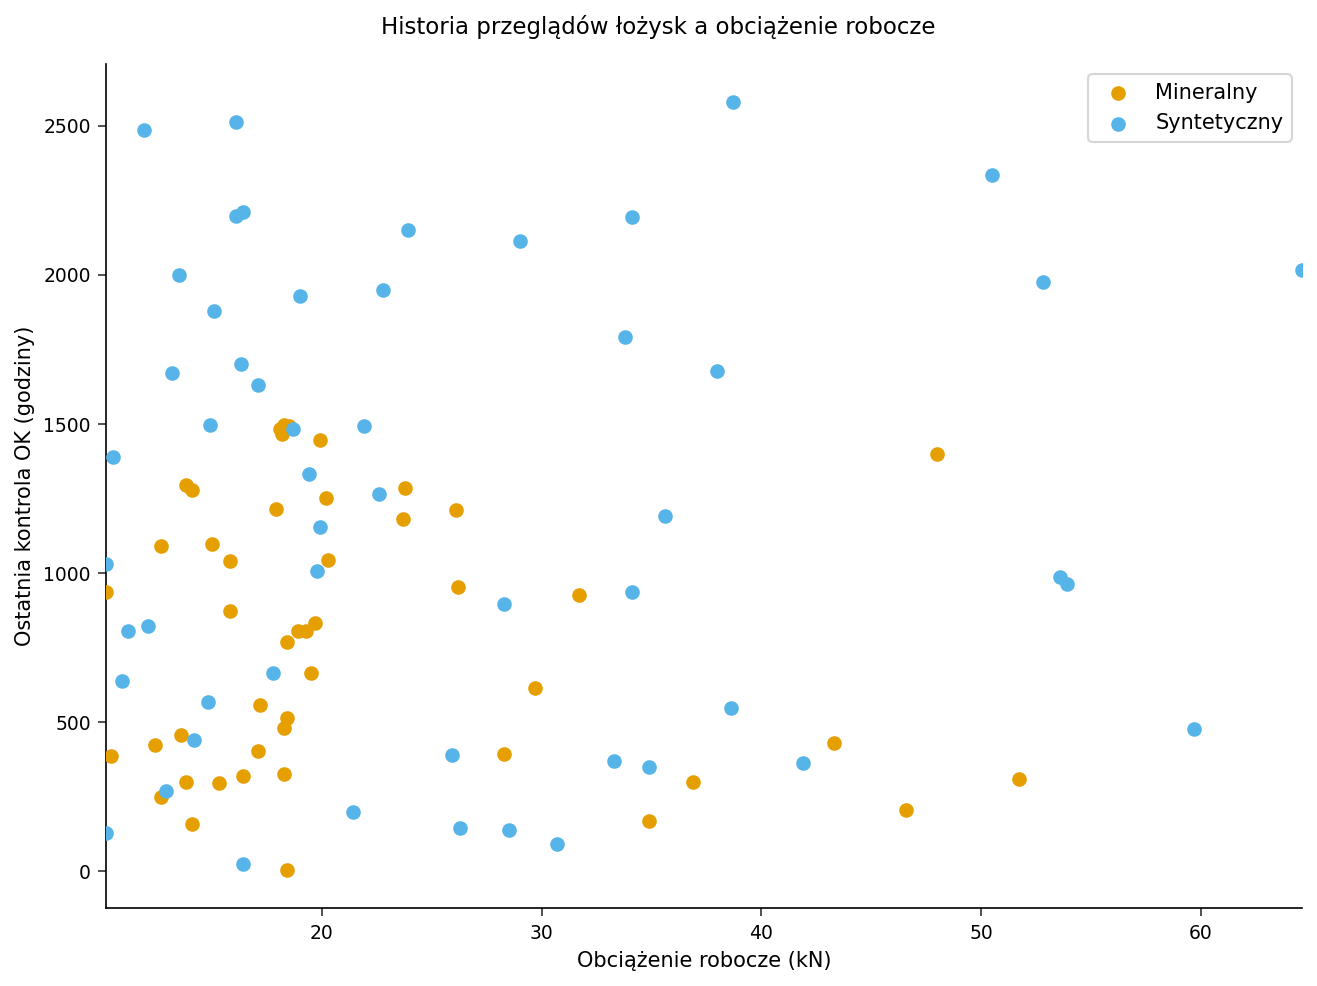

In [3]:
/* Ostatnia potwierdzona godzina kontroli OK a obciążenie, według rodzaju smaru */
PROCEDURA SGPLOT DANE=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS ETYKIETA='Obciążenie robocze (kN)';
    YAXIS ETYKIETA='Ostatnia kontrola OK (godziny)';
    TYTUŁ 'Historia przeglądów łożysk a obciążenie robocze';
WYKONAJ;

---

### Przeżycie ucięte przedziałowo według rodzaju smaru

PROC ICLIFETEST oblicza nieparametryczne oszacowanie największej wiarygodności Turnbulla funkcji przeżycia wolnego od zużycia dla każdej warstwy smaru, zapisuje pełną tabelę przeżycia do pliku `surv_estimates.csv` i renderuje wykres przeżycia w podziale na warstwy. Statystyka log-rank ucięta przedziałowo testuje równość obu rozkładów przeżycia.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        last_ok_hours
Right Bound Variable       first_worn_hours
Stratum Variable           Rodzaj smaru



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


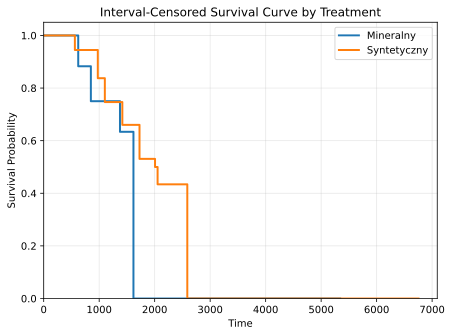

In [4]:
/* Oszacowanie przeżycia Turnbulla + wykres przeżycia w podziale na warstwy + test log-rank */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROCEDURA ICLIFETEST DANE=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    ETYKIETA lubricant='Rodzaj smaru';
WYKONAJ;
ODS GRAPHICS OFF;

---

### Wnioski

Wszystkie poniższe liczby pochodzą bezpośrednio z wykonanej tabeli PROC MEANS,
oszacowań przeżycia Turnbulla w pliku `surv_estimates.csv` oraz z logu procedury.

- **Próba.** Spośród 100 łożysk, 53 pracowały na smarze Syntetycznym, a 47 na
  Mineralnym. Dwadzieścia jeden łożysk (11 Syntetycznych, 10 Mineralnych) nadal
  mieściło się w tolerancji podczas ostatniej kontroli i wchodzi do modelu jako
  ucięte prawostronnie.
- **Porównywalne obciążenie.** Obie grupy pracują w zbliżonych warunkach:
  średnie obciążenie 25,8 kN (Syntetyczny) wobec 21,5 kN (Mineralny) oraz
  średnia prędkość 2950 wobec 2786 obr/min. Łożyska Syntetyczne nie pracują
  w łatwiejszych warunkach &mdash; jeśli już, to niosą nieco wyższe obciążenie
  &mdash; więc różnica w przeżyciu nie jest artefaktem obciążenia.
- **Dłuższa żywotność wolna od zużycia dla smaru Syntetycznego.** Mediana czasu
  Turnbulla do progu zużycia wynosi **≈2006 godzin dla Syntetycznego wobec
  ≈1617 godzin dla Mineralnego**, czyli zysk rzędu 24%. Rozbieżność powiększa
  się w ogonie rozkładu: szacowane przeżycie wolne od zużycia po 2000 godzinach
  wynosi **0,53 dla Syntetycznego, ale 0,00 dla Mineralnego**, a Syntetyczny
  utrzymuje dodatnie przeżycie aż do ≈2580 godzin, podczas gdy oszacowanie dla
  Mineralnego osiąga zero już około 1650 godzin.
- **Odrzucenie równości krzywych.** Test log-rank ucięty przedziałowo zgłoszony
  przez procedurę odrzuca równość obu funkcji przeżycia (p &lt; 0,0001). Podana
  wartość statystyki chi-kwadrat (1481) jest przybliżeniem opartym na polu
  powierzchni w obecnym silniku, więc to krzywe i mediany powyżej &mdash; a nie
  surowa statystyka &mdash; niosą interpretację.

**Implikacja dla konserwacji.** Przejście na smar syntetyczny wydłuża medianę
przedziału wolnego od zużycia o mniej więcej 400 godzin na łożysko. Przy
harmonogramie opartym na czasie uzasadnia to wydłużenie cyklu kontroli dla
jednostek smarowanych syntetycznie lub przeniesienie ich w pierwszej
kolejności na tryb oparty na stanie technicznym, przy zachowaniu ściślejszych
przedziałów dla łożysk smarowanych olejem mineralnym.

---

In [5]:
PROCEDURA EKSPORTUJ DANE=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Obsługiwane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>